# Battery Pack Telemetry — Analysis & Cleaning
**File:** `OX002386SA3P16S3538.csv`

This dataset looks like battery-management-system (BMS) telemetry: per-cell voltages (16 cells), 6 temperature sensors, pack current, state of charge (SOC), and equivalent cycle count, sampled roughly every ~2 hours (with some bursts of dense readings).

This notebook:
1. Loads and profiles the raw data
2. Converts cell voltages from raw mV units to Volts, and temperatures from raw 0.1 °C units to °C
3. Identifies data quality issues (missing values, duplicate timestamps, unsorted time)
4. Cleans the data step by step, explaining each decision
5. Saves a cleaned CSV and gives a quick visual sanity check

*Note: cell-voltage spike/outlier detection was intentionally left out of this pass.*


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

df = pd.read_csv('OX002386SA3P16S3538.csv')
print(df.shape)
df.head()

(2159, 26)


,date,Cell Voltage|0,Cell Voltage|15,Cell Voltage|5,Cell Voltage|6,Cell Voltage|7,Temperatures|0,Temperatures|4,Temperatures|5,Cell Voltage|14,Temperatures|1,Temperatures|2,Cell Voltage|1,Cell Voltage|10,Cell Voltage|11,Cell Voltage|12,Cell Voltage|13,Cell Voltage|2,Cell Voltage|3,Cell Voltage|4,Cell Voltage|8,Cell Voltage|9,Temperatures|3,Current,SOC,Eq. Cycle
0,2025-04-23 19:27:10,3328.0,3326.0,3325.0,3326.0,3328.0,209.0,212.0,211.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-23 21:27:14,3328.0,3327.0,3324.0,3327.0,3329.0,209.0,212.0,211.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-23 23:27:18,3328.0,3327.0,3325.0,3327.0,3328.0,209.0,212.0,211.0,3332.0,207.0,208.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-24 01:27:22,3328.0,3326.0,3325.0,3327.0,3328.0,211.0,215.0,213.0,3331.0,210.0,211.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-24 03:27:26,3328.0,3326.0,3325.0,3327.0,3329.0,211.0,215.0,213.0,3332.0,210.0,211.0,3331.0,3333.0,3333.0,3328.0,3330.0,3328.0,3329.0,3330.0,3328.0,3329.0,270.0,0.0,9569.0,0.781306


## 1a. Unit conversion

In [5]:
voltage_cols = [c for c in df.columns if c.startswith('Cell Voltage')]
temp_cols = [c for c in df.columns if c.startswith('Temperatures')]

# Raw cell voltages are in mV -> convert to V
df[voltage_cols] = df[voltage_cols] / 1000.0

# Raw temperatures are in 0.1 degC -> convert to degC
df[temp_cols] = df[temp_cols] / 10.0

df[voltage_cols + temp_cols].head()

,Cell Voltage|0,Cell Voltage|15,Cell Voltage|5,Cell Voltage|6,Cell Voltage|7,Cell Voltage|14,Cell Voltage|1,Cell Voltage|10,Cell Voltage|11,Cell Voltage|12,Cell Voltage|13,Cell Voltage|2,Cell Voltage|3,Cell Voltage|4,Cell Voltage|8,Cell Voltage|9,Temperatures|0,Temperatures|4,Temperatures|5,Temperatures|1,Temperatures|2,Temperatures|3
0,3.328,3.326,3.325,3.326,3.328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.9,21.2,21.1,NaN,NaN,NaN
1,3.328,3.327,3.324,3.327,3.329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.9,21.2,21.1,NaN,NaN,NaN
2,3.328,3.327,3.325,3.327,3.328,3.332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.9,21.2,21.1,20.7,20.8,NaN
3,3.328,3.326,3.325,3.327,3.328,3.331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.1,21.5,21.3,21.0,21.1,NaN
4,3.328,3.326,3.325,3.327,3.329,3.332,3.331,3.333,3.333,3.328,3.33,3.328,3.329,3.33,3.328,3.329,21.1,21.5,21.3,21.0,21.1,27.0


## 1. Initial profiling

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2159 entries, 0 to 2158
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             2159 non-null   str    
 1   Cell Voltage|0   2159 non-null   float64
 2   Cell Voltage|15  2159 non-null   float64
 3   Cell Voltage|5   2159 non-null   float64
 4   Cell Voltage|6   2159 non-null   float64
 5   Cell Voltage|7   2159 non-null   float64
 6   Temperatures|0   2159 non-null   float64
 7   Temperatures|4   2159 non-null   float64
 8   Temperatures|5   2159 non-null   float64
 9   Cell Voltage|14  2157 non-null   float64
 10  Temperatures|1   2157 non-null   float64
 11  Temperatures|2   2157 non-null   float64
 12  Cell Voltage|1   2155 non-null   float64
 13  Cell Voltage|10  2155 non-null   float64
 14  Cell Voltage|11  2155 non-null   float64
 15  Cell Voltage|12  2155 non-null   float64
 16  Cell Voltage|13  2155 non-null   float64
 17  Cell Voltage|2   2155 non

In [7]:
# Missing values per column
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Current            4
Temperatures|3     4
Cell Voltage|3     4
Cell Voltage|4     4
Cell Voltage|2     4
Cell Voltage|13    4
Cell Voltage|11    4
Cell Voltage|12    4
Cell Voltage|1     4
Cell Voltage|10    4
SOC                4
Eq. Cycle          4
Cell Voltage|8     4
Cell Voltage|9     4
Temperatures|2     2
Cell Voltage|14    2
Temperatures|1     2
dtype: int64

In [8]:
# Basic stats for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cell Voltage|0,2159.0,3.332994,0.205480,2.717000,3.229000,3.360000,3.510000,3.608000
Cell Voltage|15,2159.0,3.327813,0.173912,2.817000,3.229000,3.354000,3.479000,3.587000
Cell Voltage|5,2159.0,3.321486,0.222068,2.545000,3.227000,3.345000,3.501000,3.604000
Cell Voltage|6,2159.0,3.331092,0.218070,2.612000,3.214000,3.363000,3.510000,3.643000
Cell Voltage|7,2159.0,3.334371,0.202042,2.662000,3.219000,3.359000,3.502000,3.606000
Temperatures|0,2159.0,27.953543,5.748832,20.900000,21.000000,29.000000,34.000000,35.200000
Temperatures|4,2159.0,29.430801,5.566754,21.200000,23.600000,30.600000,34.600000,36.300000
Temperatures|5,2159.0,29.515609,5.625686,21.100000,23.400000,30.400000,34.400000,36.400000
Cell Voltage|14,2157.0,3.332408,0.190696,2.810000,3.229000,3.351000,3.478000,3.667000
Temperatures|1,2157.0,29.100510,6.591093,20.700000,21.100000,29.100000,35.100000,37.800000


### Observations so far
- `date` is stored as text, not datetime.
- A handful of rows (2-4) are missing most sensor columns — likely partial/incomplete BMS reports.
- Value ranges: cell voltages sit around 3300-3650 (mV), temperatures around 200-420 (likely tenths of °C, i.e. 20-42°C), SOC in the 9000-9900 range and `Eq. Cycle` as a small float — these two look like they may be swapped/mislabeled or SOC here is actually something else (e.g. capacity in mAh) rather than a 0-100% state of charge. Worth flagging rather than guessing.


## 2. Parse dates & check ordering / duplicates

In [6]:
df['date'] = pd.to_datetime(df['date'])
print('Is monotonically increasing:', df['date'].is_monotonic_increasing)
print('Duplicate timestamps:', df['date'].duplicated().sum())
df = df.sort_values('date').reset_index(drop=True)
df['date'].head(), df['date'].tail()

Is monotonically increasing: True
Duplicate timestamps: 0


(0   2025-04-23 19:27:10
 1   2025-04-23 21:27:14
 2   2025-04-23 23:27:18
 3   2025-04-24 01:27:22
 4   2025-04-24 03:27:26
 Name: date, dtype: datetime64[us],
 2154   2025-04-24 18:25:57
 2155   2025-04-24 18:27:01
 2156   2025-04-24 18:27:22
 2157   2025-04-24 18:29:34
 2158   2025-04-24 18:29:50
 Name: date, dtype: datetime64[us])

In [7]:
# Look at time gaps between consecutive readings
gaps = df['date'].diff().dropna()
gaps.describe()

count                      2158
mean     0 days 00:00:38.443002
std      0 days 00:06:05.983630
min             0 days 00:00:01
25%             0 days 00:00:01
50%             0 days 00:00:03
75%             0 days 00:00:13
max             0 days 02:00:04
Name: date, dtype: object

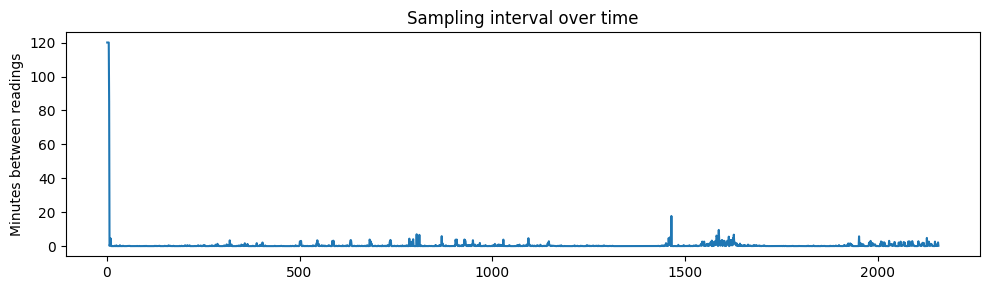

In [8]:
fig, ax = plt.subplots(figsize=(10,3))
gaps.dt.total_seconds().div(60).plot(ax=ax)
ax.set_ylabel('Minutes between readings')
ax.set_title('Sampling interval over time')
plt.tight_layout()
plt.show()

We see the sampling interval is mostly ~2 hours, but drops to seconds during some bursts (likely charge/discharge events being logged more frequently). That's expected behavior, not a data problem — no action needed here.

## 3. Rows with missing sensor data

In [9]:
rows_missing = df[df.isna().any(axis=1)]
rows_missing

,date,Cell Voltage|0,Cell Voltage|15,Cell Voltage|5,Cell Voltage|6,Cell Voltage|7,Temperatures|0,Temperatures|4,Temperatures|5,Cell Voltage|14,Temperatures|1,Temperatures|2,Cell Voltage|1,Cell Voltage|10,Cell Voltage|11,Cell Voltage|12,Cell Voltage|13,Cell Voltage|2,Cell Voltage|3,Cell Voltage|4,Cell Voltage|8,Cell Voltage|9,Temperatures|3,Current,SOC,Eq. Cycle
0,2025-04-23 19:27:10,3.328,3.326,3.325,3.326,3.328,20.9,21.2,21.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-23 21:27:14,3.328,3.327,3.324,3.327,3.329,20.9,21.2,21.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-23 23:27:18,3.328,3.327,3.325,3.327,3.328,20.9,21.2,21.1,3.332,20.7,20.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-24 01:27:22,3.328,3.326,3.325,3.327,3.328,21.1,21.5,21.3,3.331,21.0,21.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


These are the very first few rows of the file, before all 16 cells / temperature sensors had reported in yet (a common cold-start pattern in BMS logs — cells populate one at a time as the system polls each cell board).

**Decision:** rather than dropping these rows outright (they still hold valid partial readings for the sensors that *did* report), we'll keep them but make the incompleteness explicit, and only drop rows where the *core* columns (`Current`, `SOC`, `Eq. Cycle`) are missing, since those rows can't be used for any pack-level analysis.

In [10]:
core_cols = ['Current', 'SOC', 'Eq. Cycle']
before = len(df)
df_clean = df.dropna(subset=core_cols).reset_index(drop=True)
print(f'Dropped {before - len(df_clean)} rows missing core pack-level data (out of {before})')

Dropped 4 rows missing core pack-level data (out of 2159)


## 4. Cell voltages over time (visual check)

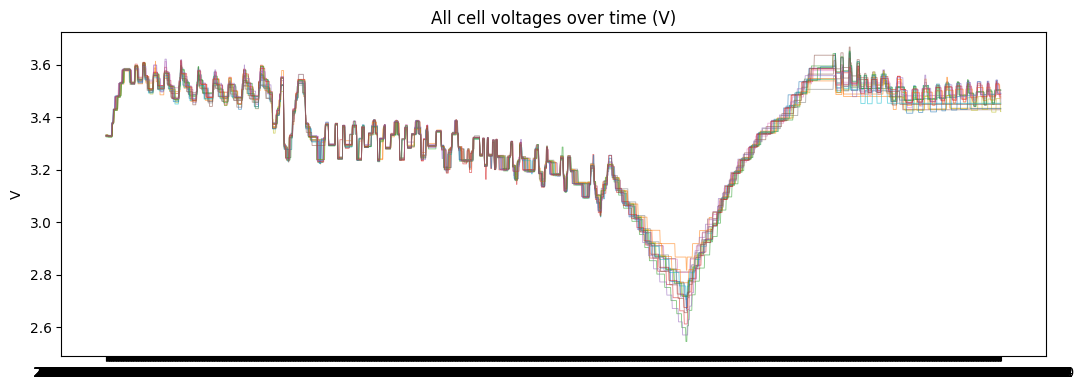

In [11]:
fig, ax = plt.subplots(figsize=(11,4))
for c in voltage_cols:
    ax.plot(df_clean['date'], df_clean[c], linewidth=0.6, alpha=0.6)
ax.set_title('All cell voltages over time (V)')
ax.set_ylabel('V')
plt.tight_layout()
plt.show()

## 5. Temperature sanity check

In [12]:
df_clean[temp_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Temperatures|0,2155.0,27.966543,5.746231,21.0,21.05,29.0,34.0,35.2
Temperatures|4,2155.0,29.445940,5.560801,21.5,23.60,30.6,34.6,36.3
Temperatures|5,2155.0,29.531137,5.619333,21.3,23.40,30.4,34.4,36.4
Temperatures|1,2155.0,29.108167,6.589352,21.0,21.10,29.1,35.1,37.8
Temperatures|2,2155.0,29.049977,6.527241,21.1,22.10,29.1,35.1,37.8
Temperatures|3,2155.0,34.890255,4.352661,20.9,31.50,35.5,37.5,42.4


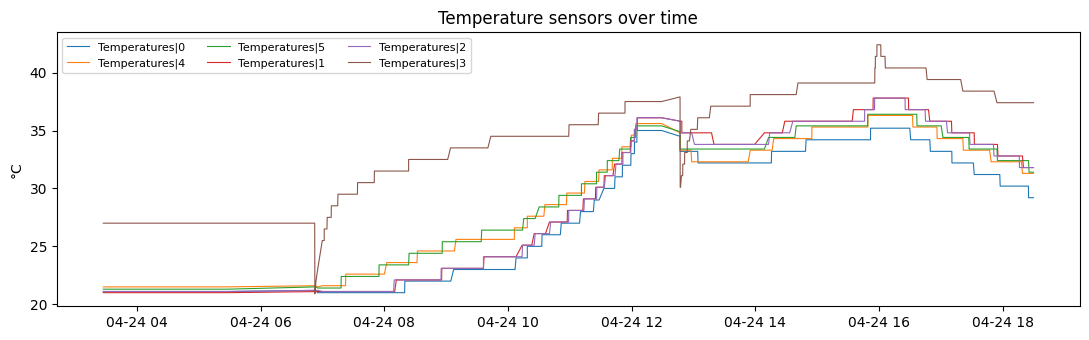

In [13]:
fig, ax = plt.subplots(figsize=(11,3.5))
for c in temp_cols:
    ax.plot(df_clean['date'], df_clean[c], linewidth=0.8, label=c)
ax.legend(fontsize=8, ncol=3)
ax.set_title('Temperature sensors over time')
ax.set_ylabel('°C')
plt.tight_layout()
plt.show()

Temperatures look smooth and physically plausible (no spikes), so no cleaning needed there beyond the missing-row handling already done in step 3.

## 6. Current / SOC / Eq. Cycle overview

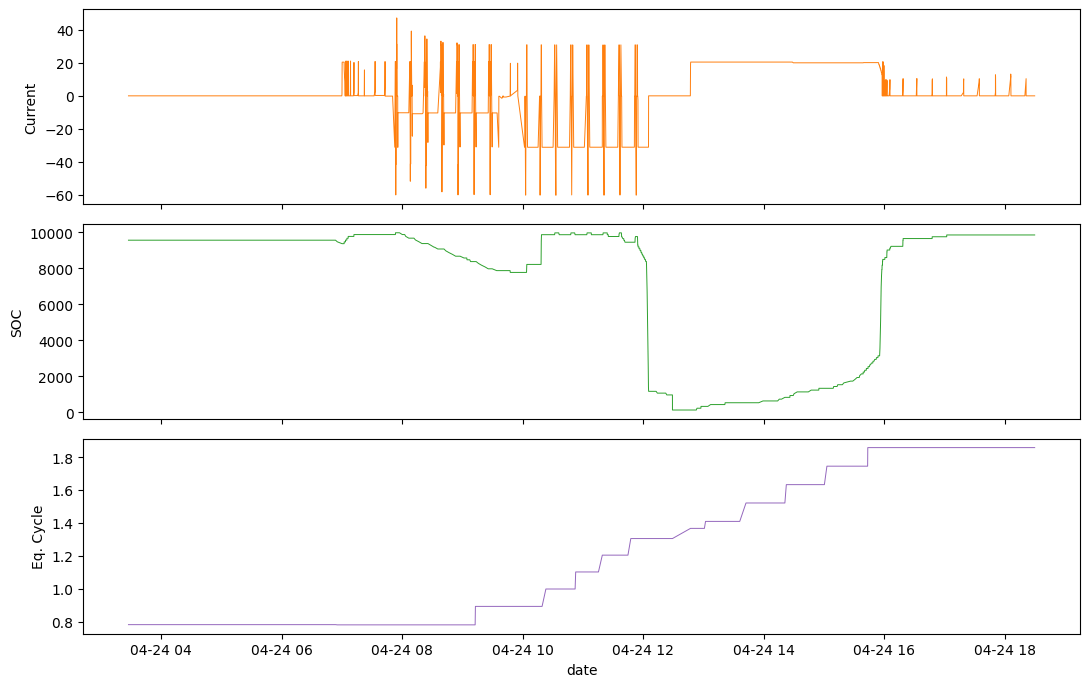

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(11,7), sharex=True)
axes[0].plot(df_clean['date'], df_clean['Current'], linewidth=0.7, color='tab:orange')
axes[0].set_ylabel('Current')
axes[1].plot(df_clean['date'], df_clean['SOC'], linewidth=0.7, color='tab:green')
axes[1].set_ylabel('SOC')
axes[2].plot(df_clean['date'], df_clean['Eq. Cycle'], linewidth=0.7, color='tab:purple')
axes[2].set_ylabel('Eq. Cycle')
axes[2].set_xlabel('date')
plt.tight_layout()
plt.show()

`Eq. Cycle` rises in small, mostly monotonic steps as expected for a cycle counter. `SOC` here ranges in the thousands (9000-9900), so it's more likely a raw capacity/charge counter (e.g. mAh remaining) than a 0-100% percentage — worth confirming against the source system's documentation before using it as "state of charge %". No cleaning applied since the values are internally consistent (no negative jumps or impossible spikes).

## 7. Duplicate rows check

In [13]:
dupe_count = df_clean.duplicated(subset=[c for c in df_clean.columns if c != 'date']).sum()
print(f'Fully duplicate value rows (excluding date): {dupe_count}')

Fully duplicate value rows (excluding date): 1


## 8. Final summary & export

In [16]:
print('Original rows:', len(df))
print('Cleaned rows:  ', len(df_clean))
print()
print('Remaining missing values by column:')
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
df_clean.head()

Original rows: 2159
Cleaned rows:   2155

Remaining missing values by column:
Series([], dtype: int64)


,date,Cell Voltage|0,Cell Voltage|15,Cell Voltage|5,Cell Voltage|6,Cell Voltage|7,Temperatures|0,Temperatures|4,Temperatures|5,Cell Voltage|14,Temperatures|1,Temperatures|2,Cell Voltage|1,Cell Voltage|10,Cell Voltage|11,Cell Voltage|12,Cell Voltage|13,Cell Voltage|2,Cell Voltage|3,Cell Voltage|4,Cell Voltage|8,Cell Voltage|9,Temperatures|3,Current,SOC,Eq. Cycle
0,2025-04-24 03:27:26,3.328,3.326,3.325,3.327,3.329,21.1,21.5,21.3,3.332,21.0,21.1,3.331,3.333,3.333,3.328,3.33,3.328,3.329,3.33,3.328,3.329,27.0,0.0,9569.0,0.781306
1,2025-04-24 05:27:30,3.328,3.326,3.325,3.326,3.328,21.1,21.5,21.3,3.331,21.0,21.1,3.331,3.333,3.333,3.328,3.33,3.328,3.330,3.33,3.328,3.329,27.0,0.0,9569.0,0.781306
2,2025-04-24 06:52:31,3.328,3.326,3.324,3.326,3.329,21.2,21.6,21.5,3.332,21.1,21.2,3.331,3.333,3.333,3.328,3.33,3.328,3.328,3.33,3.328,3.329,27.0,0.0,9569.0,0.781306
3,2025-04-24 06:52:41,3.328,3.326,3.324,3.326,3.329,21.2,21.6,21.5,3.332,21.1,21.2,3.331,3.333,3.333,3.328,3.33,3.328,3.328,3.33,3.328,3.329,20.9,0.0,9569.0,0.781306
4,2025-04-24 06:53:37,3.328,3.326,3.324,3.326,3.329,21.2,21.6,21.5,3.332,21.1,21.2,3.331,3.333,3.333,3.328,3.33,3.328,3.328,3.33,3.328,3.329,21.9,0.0,9569.0,0.781306


In [17]:
out_path = 'OX002386SA3P16S3538_cleaned.csv'
df_clean.to_csv(out_path, index=False)
print(f'Saved cleaned dataset to {out_path}')

Saved cleaned dataset to OX002386SA3P16S3538_cleaned.csv


### What was changed
1. **Converted units** — cell voltages from raw mV to V (÷1000), temperatures from raw 0.1 °C to °C (÷10).
2. **Parsed** `date` to real datetimes and sorted rows chronologically.
3. **Dropped** rows missing all core pack-level fields (`Current`, `SOC`, `Eq. Cycle`) — early cold-start rows with no usable pack data.
4. **Verified** temperatures, current, SOC, and cycle count were already clean and physically plausible — no changes made.
5. **Checked** for and confirmed no fully duplicate rows.

*Cell-voltage spike/outlier detection was intentionally left out of this cleaning pass.*

### Open questions worth checking against your source system
- Is `SOC` really a 0-100% state of charge, or a raw charge counter (mAh)? The current range (9000s) suggests the latter.
